<a href="https://colab.research.google.com/github/pnhongngoc37-cloud/TH_DeepLearning/blob/main/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ERROR: Could not find a version that satisfies the requirement vietnamese-fonts (from versions: none)
ERROR: No matching distribution found for vietnamese-fonts
ĐANG TẠO DỮ LIỆU MẪU...
✅ Đã tạo dữ liệu thành công! Số lượng: 5000 thí sinh
        DH1       DH2       DH3        T1   GT    DT KV KhoiThi  KT KQXT XL1  \
0  5.551581  5.780268  7.273019  7.004623  Nam  Kinh  3       A   A  Đậu   K   
1  5.147455  3.434793  3.870205  5.973860  Nam  Kinh  3      A1  A1  Rớt  TB   
2  5.699610  5.597263  7.435818  6.780854   Nữ  Kinh  2       A   A  Đậu   K   
3  4.486862  4.990275  4.975588  3.786191   Nữ  Thái  3       D   D  Rớt  TB   
4  9.784755  5.063612  6.553102  9.614532  Nam  Kinh  1       D   D  Đậu  XS   

  XL2 XL3   US_TBM1   US_TBM2   US_TBM3  
0   K   G  8.171507  6.447074  9.815369  
1   Y   Y  9.333893  9.492613  5.947617  
2   K   G  9.266377  9.055233  6.978804  
3  TB  TB  9.862338  5.156426  5.907412  
4  TB   K  5.523456  4.934304  6.845779  

Thông tin các cột:
<class 'p

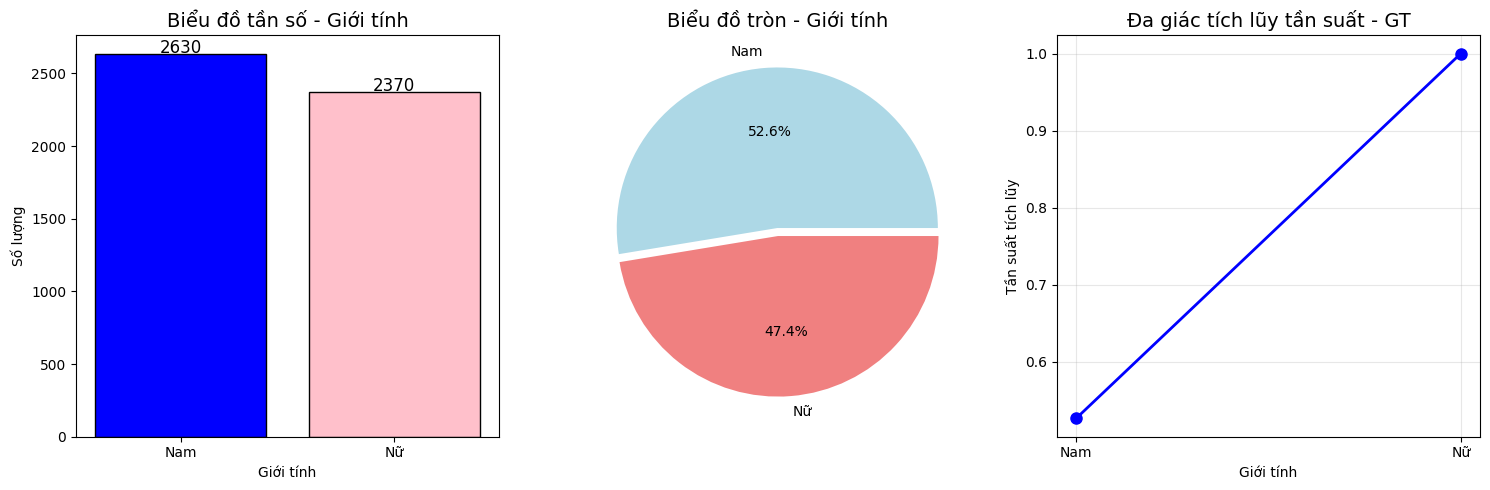


2. PHÂN TÍCH US_TBM1, US_TBM2, US_TBM3:


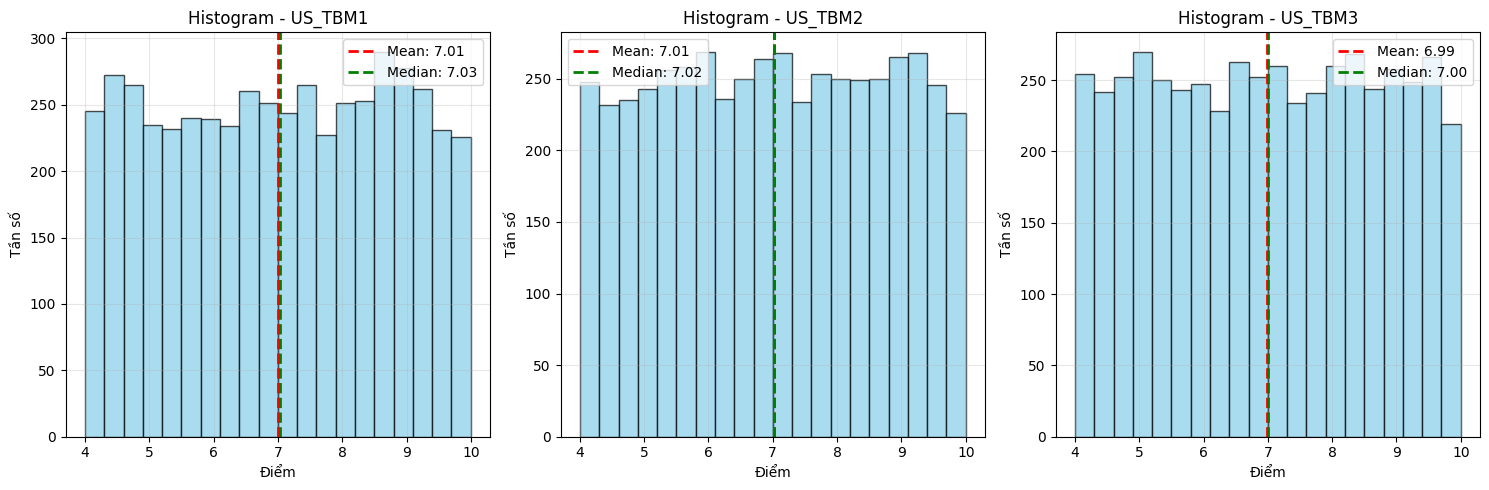


3. PHÂN BỐ DÂN TỘC (HỌC SINH NAM):
DT
Kinh     2056
Khác      263
Tày       119
Thái      109
Mường      83
Name: count, dtype: int64

4. PHÂN BỐ KV (Nam, Kinh, DH1>=5, DH2>=4, DH3>=4):
KV
3      364
1      329
2      303
2NT    138
Name: count, dtype: int64

5. Số lượng thí sinh DH1,DH2,DH3>=5 và KV=2NT: 224
          DH1        DH2        DH3   KV
51   8.028132   6.017102  10.000000  2NT
99   5.180805   8.634975   6.996776  2NT
146  5.909783   8.337903   6.513693  2NT
171  5.643490   6.488355   6.057308  2NT
174  9.453267  10.000000   6.757228  2NT

PHẦN 3: TRỰC QUAN HÓA THEO NHÓM PHÂN LOẠI


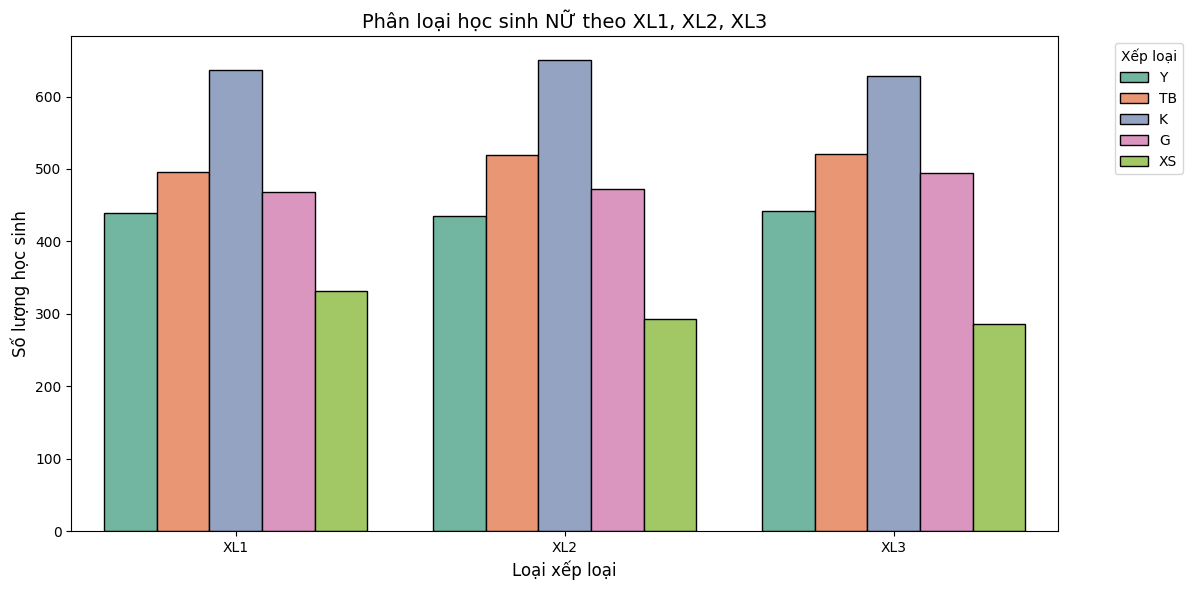

TypeError: no numeric data to plot

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# Cài đặt font chữ cho tiếng Việt (nếu cần)
!pip install -q vietnamese-fonts
import matplotlib.font_manager as fm
# Tạo font chữ mặc định hỗ trợ tiếng Việt
plt.rcParams['font.family'] = 'DejaVu Sans'

# ============================================
# 1. TẠO DỮ LIỆU MẪU (SIMULATED DATA)
# ============================================
print("="*60)
print("ĐANG TẠO DỮ LIỆU MẪU...")
print("="*60)

np.random.seed(42)
n_samples = 5000  # 5000 thí sinh

# Tạo điểm T1 (Toán) - phân phối hơi lệch trái (thiên về khá giỏi)
T1_scores = np.random.beta(a=2, b=1.5, size=n_samples) * 10
T1_scores = np.clip(T1_scores, 0, 10)

# Tạo các điểm thi khác với tương quan
DH1 = T1_scores * 0.7 + np.random.normal(2, 1.5, n_samples)
DH1 = np.clip(DH1, 0, 10)

DH2 = T1_scores * 0.65 + np.random.normal(2.2, 1.6, n_samples)
DH2 = np.clip(DH2, 0, 10)

DH3 = T1_scores * 0.6 + np.random.normal(2.5, 1.7, n_samples)
DH3 = np.clip(DH3, 0, 10)

# Các biến phân loại
GT = np.random.choice(['Nam', 'Nữ'], n_samples, p=[0.52, 0.48])
DT = np.random.choice(['Kinh', 'Tày', 'Thái', 'Mường', 'Khác'], n_samples, p=[0.78, 0.05, 0.04, 0.03, 0.10])
KV = np.random.choice([1, 2, 3, '2NT'], n_samples, p=[0.32, 0.28, 0.30, 0.10])
KhoiThi = np.random.choice(['A', 'A1', 'B', 'C', 'D'], n_samples, p=[0.25, 0.20, 0.20, 0.20, 0.15])

# Tạo KQXT (Kết quả xét tuyển) dựa trên điểm
avg_score = (DH1 + DH2 + DH3) / 3
KQXT = np.where(avg_score >= 5, 'Đậu', 'Rớt')

# Tạo xếp loại học lực
def xep_loai(score):
    if score < 4: return 'Y'
    elif score < 5.5: return 'TB'
    elif score < 7: return 'K'
    elif score < 8.5: return 'G'
    else: return 'XS'

XL1 = [xep_loai(s) for s in DH1]
XL2 = [xep_loai(s) for s in DH2]
XL3 = [xep_loai(s) for s in DH3]

# Tạo US_TBM (Điểm trung bình môn)
US_TBM1 = np.random.uniform(4, 10, n_samples)
US_TBM2 = np.random.uniform(4, 10, n_samples)
US_TBM3 = np.random.uniform(4, 10, n_samples)

# Tạo biến KT (khối thi) - đồng nhất với KhoiThi
KT = KhoiThi.copy()

# Tạo DataFrame
df = pd.DataFrame({
    'DH1': DH1,
    'DH2': DH2,
    'DH3': DH3,
    'T1': T1_scores,
    'GT': GT,
    'DT': DT,
    'KV': KV,
    'KhoiThi': KhoiThi,
    'KT': KT,
    'KQXT': KQXT,
    'XL1': XL1,
    'XL2': XL2,
    'XL3': XL3,
    'US_TBM1': US_TBM1,
    'US_TBM2': US_TBM2,
    'US_TBM3': US_TBM3
})

print(f"✅ Đã tạo dữ liệu thành công! Số lượng: {len(df)} thí sinh")
print(df.head())
print("\nThông tin các cột:")
print(df.info())

# ============================================
# PHẦN 1: THỐNG KÊ DỮ LIỆU
# ============================================
print("\n" + "="*60)
print("PHẦN 1: THỐNG KÊ DỮ LIỆU")
print("="*60)

# 1. Sắp xếp DH1 tăng dần
df_sorted_DH1 = df.sort_values('DH1')
print("\n1. 5 giá trị DH1 nhỏ nhất:", df_sorted_DH1['DH1'].head().tolist())
print("   5 giá trị DH1 lớn nhất:", df_sorted_DH1['DH1'].tail().tolist())

# 2. Sắp xếp DH2 tăng dần theo nhóm giới tính
df_sorted_DH2_by_GT = df.sort_values(['GT', 'DH2'])
print("\n2. Sắp xếp DH2 theo GT (Nam trước):")
print(df_sorted_DH2_by_GT[['GT', 'DH2']].head(10))

# 3. Pivot table DH1 theo KT
def q1(x): return x.quantile(0.25)
def q3(x): return x.quantile(0.75)
pivot_KT = df.groupby('KT')['DH1'].agg(['count', 'sum', 'mean', 'median', 'min', 'max', 'std', q1, q3])
pivot_KT.columns = ['Số lượng', 'Tổng', 'Trung bình', 'Trung vị', 'Min', 'Max', 'Std', 'Q1', 'Q3']
print("\n3. Pivot Table DH1 theo KT:")
print(pivot_KT)

# 4. Pivot table DH1 theo KT và KV
pivot_KT_KV = df.groupby(['KT', 'KV'])['DH1'].agg(['count', 'mean', 'median', 'std'])
pivot_KT_KV.columns = ['Số lượng', 'Trung bình', 'Trung vị', 'Std']
print("\n4. Pivot Table DH1 theo KT và KV:")
print(pivot_KT_KV)

# 5. Pivot table DH1 theo KT, KV, DT
pivot_full = df.groupby(['KT', 'KV', 'DT'])['DH1'].agg(['count', 'mean', 'median', 'min', 'max'])
pivot_full.columns = ['Số lượng', 'Trung bình', 'Trung vị', 'Min', 'Max']
print("\n5. Pivot Table DH1 theo KT, KV, DT:")
print(pivot_full)

# ============================================
# PHẦN 2: TRÌNH BÀY DỮ LIỆU
# ============================================
print("\n" + "="*60)
print("PHẦN 2: TRÌNH BÀY DỮ LIỆU")
print("="*60)

# 1. Trình bày biến GT
print("\n1. PHÂN TÍCH BIẾN GT:")
freq_GT = df['GT'].value_counts()
freq_percent_GT = df['GT'].value_counts(normalize=True) * 100
print("Bảng tần số:")
print(pd.DataFrame({'Tần số': freq_GT, 'Tần suất (%)': freq_percent_GT}))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Biểu đồ tần số (cột)
axes[0].bar(freq_GT.index, freq_GT.values, color=['blue', 'pink'], edgecolor='black')
axes[0].set_title('Biểu đồ tần số - Giới tính', fontsize=14)
axes[0].set_xlabel('Giới tính')
axes[0].set_ylabel('Số lượng')
for i, v in enumerate(freq_GT.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=12)

# Biểu đồ tần suất (tròn)
axes[1].pie(freq_GT.values, labels=freq_GT.index, autopct='%1.1f%%',
            colors=['lightblue', 'lightcoral'], explode=(0.05, 0))
axes[1].set_title('Biểu đồ tròn - Giới tính', fontsize=14)

# Biểu đồ tích lũy tần suất
cumsum = df['GT'].value_counts(normalize=True).cumsum()
axes[2].plot(cumsum.index, cumsum.values, 'bo-', linewidth=2, markersize=8)
axes[2].set_title('Đa giác tích lũy tần suất - GT', fontsize=14)
axes[2].set_xlabel('Giới tính')
axes[2].set_ylabel('Tần suất tích lũy')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Trình bày US_TBM1, US_TBM2, US_TBM3
print("\n2. PHÂN TÍCH US_TBM1, US_TBM2, US_TBM3:")
us_tbm_cols = ['US_TBM1', 'US_TBM2', 'US_TBM3']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, col in enumerate(us_tbm_cols):
    axes[idx].hist(df[col], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.2f}')
    axes[idx].axvline(df[col].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df[col].median():.2f}')
    axes[idx].set_title(f'Histogram - {col}', fontsize=12)
    axes[idx].set_xlabel('Điểm')
    axes[idx].set_ylabel('Tần số')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Trình bày DT với học sinh nam
df_nam = df[df['GT'] == 'Nam']
freq_DT_nam = df_nam['DT'].value_counts()
print("\n3. PHÂN BỐ DÂN TỘC (HỌC SINH NAM):")
print(freq_DT_nam)

# 4. Trình bày KV với nam, Kinh, điểm DH1>=5, DH2>=4, DH3>=4
cond = (df['GT'] == 'Nam') & (df['DT'] == 'Kinh') & (df['DH1'] >= 5) & (df['DH2'] >= 4) & (df['DH3'] >= 4)
df_filtered = df[cond]
freq_KV_filtered = df_filtered['KV'].value_counts()
print("\n4. PHÂN BỐ KV (Nam, Kinh, DH1>=5, DH2>=4, DH3>=4):")
print(freq_KV_filtered)

# 5. Trình bày DH1, DH2, DH3 >=5 và KV=2NT
cond2 = (df['DH1'] >= 5) & (df['DH2'] >= 5) & (df['DH3'] >= 5) & (df['KV'] == '2NT')
df_2NT = df[cond2]
print(f"\n5. Số lượng thí sinh DH1,DH2,DH3>=5 và KV=2NT: {len(df_2NT)}")
if len(df_2NT) > 0:
    print(df_2NT[['DH1', 'DH2', 'DH3', 'KV']].head())

# ============================================
# PHẦN 3: TRỰC QUAN HÓA THEO NHÓM PHÂN LOẠI
# ============================================
print("\n" + "="*60)
print("PHẦN 3: TRỰC QUAN HÓA THEO NHÓM PHÂN LOẠI")
print("="*60)

# 1. Học sinh nữ trên XL1, XL2, XL3 dạng unstacked
df_nu = df[df['GT'] == 'Nữ']
xl_cols = ['XL1', 'XL2', 'XL3']
df_nu_melted = df_nu.melt(id_vars=['GT'], value_vars=xl_cols, var_name='LoaiXL', value_name='XepLoai')
order = ['Y', 'TB', 'K', 'G', 'XS']
plt.figure(figsize=(12, 6))
sns.countplot(data=df_nu_melted, x='LoaiXL', hue='XepLoai', hue_order=order,
              palette='Set2', edgecolor='black')
plt.title('Phân loại học sinh NỮ theo XL1, XL2, XL3', fontsize=14)
plt.xlabel('Loại xếp loại', fontsize=12)
plt.ylabel('Số lượng học sinh', fontsize=12)
plt.legend(title='Xếp loại', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 2. KQXT trên nhóm khối thi A, A1, B thuộc KV 1,2
df_khoi_KV = df[df['KhoiThi'].isin(['A', 'A1', 'B']) & df['KV'].isin([1, 2])]
crosstab_kqxt = pd.crosstab(df_khoi_KV['KhoiThi'], df_khoi_KV['KQXT'])
crosstab_kqxt.plot(kind='bar', stacked=False, color=['red', 'green'], edgecolor='black', figsize=(10, 6))
plt.title('Kết quả xét tuyển theo khối thi (KV 1,2)', fontsize=14)
plt.xlabel('Khối thi', fontsize=12)
plt.ylabel('Số lượng thí sinh', fontsize=12)
plt.legend(title='KQXT')
plt.xticks(rotation=0)
for i in range(len(crosstab_kqxt.index)):
    for j in range(len(crosstab_kqxt.columns)):
        plt.text(i, crosstab_kqxt.iloc[i, :j+1].sum() - crosstab_kqxt.iloc[i, j]/2,
                str(crosstab_kqxt.iloc[i, j]), ha='center', va='center', fontsize=10)
plt.tight_layout()
plt.show()

# 3. Số lượng thí sinh từng KV theo từng nhóm khối thi
crosstab_kv_khoi = pd.crosstab(df['KV'], df['KhoiThi'])
crosstab_kv_khoi.plot(kind='bar', stacked=True, figsize=(12, 6), edgecolor='black')
plt.title('Số lượng thí sinh theo KV và khối thi', fontsize=14)
plt.xlabel('Khu vực', fontsize=12)
plt.ylabel('Số lượng thí sinh', fontsize=12)
plt.legend(title='Khối thi', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Số lượng đậu/rớt theo khối thi
crosstab_khoi_kqxt = pd.crosstab(df['KhoiThi'], df['KQXT'])
crosstab_khoi_kqxt.plot(kind='bar', stacked=False, color=['lightcoral', 'lightgreen'], edgecolor='black', figsize=(12, 6))
plt.title('Số lượng thí sinh Đậu/Rớt theo khối thi', fontsize=14)
plt.xlabel('Khối thi', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.legend(title='KQXT')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. Số lượng đậu/rớt theo KV
crosstab_kv_kqxt = pd.crosstab(df['KV'], df['KQXT'])
crosstab_kv_kqxt.plot(kind='bar', stacked=False, color=['lightcoral', 'lightgreen'], edgecolor='black', figsize=(12, 6))
plt.title('Số lượng thí sinh Đậu/Rớt theo khu vực', fontsize=14)
plt.xlabel('Khu vực', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.legend(title='KQXT')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 6. Số lượng đậu/rớt theo DT
crosstab_dt_kqxt = pd.crosstab(df['DT'], df['KQXT'])
crosstab_dt_kqxt.plot(kind='bar', stacked=False, color=['lightcoral', 'lightgreen'], edgecolor='black', figsize=(12, 6))
plt.title('Số lượng thí sinh Đậu/Rớt theo dân tộc', fontsize=14)
plt.xlabel('Dân tộc', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.legend(title='KQXT')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7. Số lượng đậu/rớt theo GT
crosstab_gt_kqxt = pd.crosstab(df['GT'], df['KQXT'])
crosstab_gt_kqxt.plot(kind='bar', stacked=False, color=['lightcoral', 'lightgreen'], edgecolor='black', figsize=(8, 6))
plt.title('Số lượng thí sinh Đậu/Rớt theo giới tính', fontsize=14)
plt.xlabel('Giới tính', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.legend(title='KQXT')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ============================================
# PHẦN 4: TRỰC QUAN HÓA NÂNG CAO
# ============================================
print("\n" + "="*60)
print("PHẦN 4: TRỰC QUAN HÓA NÂNG CAO")
print("="*60)

# 1. Tạo biến phân loại phanlopt1
def classify_T1(score):
    if score < 5:
        return 'kém'
    elif score < 7:
        return 'trung bình'
    elif score < 8:
        return 'khá'
    else:
        return 'giỏi'

df['phanlopt1'] = df['T1'].apply(classify_T1)

# 2. Bảng tần số cho phanloait1
print("\n1. BẢNG TẦN SỐ CHO PHANLOPT1:")
freq_phanloai = df['phanlopt1'].value_counts()
freq_percent_phanloai = df['phanlopt1'].value_counts(normalize=True) * 100
freq_table_phanloai = pd.DataFrame({'Tần số': freq_phanloai, 'Tần suất (%)': freq_percent_phanloai})
print(freq_table_phanloai)

# 3. Biểu đồ đường Simple cho T1
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(df['T1'].sort_values().reset_index(drop=True), 'b-', linewidth=1, alpha=0.7)
plt.title('Simple Line Chart - T1 (sắp xếp tăng dần)', fontsize=12)
plt.xlabel('Index (sau khi sắp xếp)')
plt.ylabel('Điểm T1')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(df['T1'].values, 'g-', linewidth=0.5, alpha=0.5)
plt.title('Simple Line Chart - T1 (thứ tự gốc)', fontsize=12)
plt.xlabel('Thứ tự thí sinh')
plt.ylabel('Điểm T1')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Biểu đồ đường Multiple Line cho T1 theo phanlopt1
plt.figure(figsize=(14, 6))
categories = ['kém', 'trung bình', 'khá', 'giỏi']
colors = {'kém': 'red', 'trung bình': 'orange', 'khá': 'blue', 'giỏi': 'green'}

for cat in categories:
    subset = df[df['phanlopt1'] == cat]['T1'].sort_values().reset_index(drop=True)
    plt.plot(subset, label=f'{cat} (n={len(subset)})', color=colors[cat], linewidth=1.5, alpha=0.8)

plt.title('Multiple Line Chart - T1 phân loại theo phanlopt1', fontsize=14)
plt.xlabel('Index (sắp xếp trong nhóm)')
plt.ylabel('Điểm T1')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# 5. Biểu đồ Drop-line cho T1 theo phanlopt1
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, cat in enumerate(categories):
    subset = df[df['phanlopt1'] == cat]['T1'].sort_values().reset_index(drop=True)
    # Giới hạn hiển thị 200 điểm để biểu đồ rõ ràng
    if len(subset) > 200:
        subset = subset.head(200)
    axes[idx].stem(subset.values, linefmt=f'C{idx}-', markerfmt=f'C{idx}o', basefmt='k-')
    axes[idx].set_title(f'Drop-line Chart - {cat} (n={len(subset)})', fontsize=12)
    axes[idx].set_xlabel('Thí sinh (sắp xếp theo điểm)')
    axes[idx].set_ylabel('Điểm T1')
    axes[idx].set_ylim(0, 10)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# PHẦN 5: MÔ TẢ VÀ KHẢO SÁT PHÂN PHỐI
# ============================================
print("\n" + "="*60)
print("PHẦN 5: MÔ TẢ VÀ KHẢO SÁT PHÂN PHỐI T1")
print("="*60)

# 1. Thống kê mô tả
print("\n1. THỐNG KÊ MÔ TẢ T1:")
print(f"Số lượng: {len(df['T1'])}")
print(f"Trung bình (Mean): {df['T1'].mean():.3f}")
print(f"Trung vị (Median): {df['T1'].median():.3f}")
print(f"Giá trị nhỏ nhất: {df['T1'].min():.3f}")
print(f"Giá trị lớn nhất: {df['T1'].max():.3f}")
print(f"Phương sai: {df['T1'].var():.3f}")
print(f"Độ lệch chuẩn: {df['T1'].std():.3f}")
print(f"Độ bất đối xứng (Skewness): {df['T1'].skew():.3f}")
print(f"Độ nhọn (Kurtosis): {df['T1'].kurtosis():.3f}")

# 2. Box-Plot
plt.figure(figsize=(10, 6))
box = plt.boxplot(df['T1'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='blue'),
                   whiskerprops=dict(color='blue'),
                   capprops=dict(color='blue'),
                   medianprops=dict(color='red', linewidth=2),
                   flierprops=dict(marker='o', markerfacecolor='red', markersize=6, alpha=0.5))

plt.title('Box-Plot của biến T1', fontsize=14)
plt.ylabel('Điểm T1', fontsize=12)
plt.xticks([1], ['T1'])

# Tính các đại lượng
Q1 = df['T1'].quantile(0.25)
Q2 = df['T1'].median()
Q3 = df['T1'].quantile(0.75)
IQR = Q3 - Q1
lower_whisker = df['T1'][df['T1'] >= Q1 - 1.5*IQR].min()
upper_whisker = df['T1'][df['T1'] <= Q3 + 1.5*IQR].max()
outliers = df['T1'][(df['T1'] < Q1 - 1.5*IQR) | (df['T1'] > Q3 + 1.5*IQR)]

print("\n2. 10 ĐẠI LƯỢNG TRONG BOX-PLOT:")
print(f"  Q1 (Tứ phân vị thứ nhất): {Q1:.3f}")
print(f"  Q2 (Trung vị): {Q2:.3f}")
print(f"  Q3 (Tứ phân vị thứ ba): {Q3:.3f}")
print(f"  IQR (Khoảng tứ phân vị): {IQR:.3f}")
print(f"  Giới hạn dưới (Lower fence): {Q1 - 1.5*IQR:.3f}")
print(f"  Giới hạn trên (Upper fence): {Q3 + 1.5*IQR:.3f}")
print(f"  Râu dưới (Lower whisker): {lower_whisker:.3f}")
print(f"  Râu trên (Upper whisker): {upper_whisker:.3f}")
print(f"  Số lượng outlier: {len(outliers)}")
print(f"  Min (không kể outlier): {lower_whisker:.3f}, Max: {upper_whisker:.3f}")

plt.grid(True, alpha=0.3)
plt.show()

# 3. Histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['T1'], bins=20, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(df['T1'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["T1"].mean():.2f}')
axes[0].axvline(df['T1'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["T1"].median():.2f}')
axes[0].set_title('Histogram của T1', fontsize=14)
axes[0].set_xlabel('Điểm T1')
axes[0].set_ylabel('Tần số')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sns.histplot(df['T1'], bins=20, kde=True, ax=axes[1], color='purple', alpha=0.6)
axes[1].axvline(df['T1'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["T1"].mean():.2f}')
axes[1].axvline(df['T1'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["T1"].median():.2f}')
axes[1].set_title('Histogram với KDE của T1', fontsize=14)
axes[1].set_xlabel('Điểm T1')
axes[1].set_ylabel('Mật độ')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. QQ-Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# QQ-plot
stats.probplot(df['T1'], dist="norm", plot=axes[0])
axes[0].set_title('QQ-Plot: T1 vs Phân phối Chuẩn', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Histogram với đường cong chuẩn
sns.histplot(df['T1'], bins=20, kde=True, stat='density', ax=axes[1], color='skyblue', alpha=0.6)
x = np.linspace(df['T1'].min(), df['T1'].max(), 100)
axes[1].plot(x, stats.norm.pdf(x, df['T1'].mean(), df['T1'].std()), 'r-', linewidth=2, label='Phân phối chuẩn')
axes[1].set_title('Histogram với đường cong phân phối chuẩn', fontsize=14)
axes[1].set_xlabel('Điểm T1')
axes[1].set_ylabel('Mật độ')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Phân phối T1 theo từng nhóm phanlopt1
print("\n3. PHÂN PHỐI T1 THEO TỪNG NHÓM PHANLOPT1:")
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for idx, cat in enumerate(categories):
    subset = df[df['phanlopt1'] == cat]['T1']

    # Box-plot
    axes[0, idx].boxplot(subset, vert=True, patch_artist=True)
    axes[0, idx].set_title(f'Box-plot: {cat} (n={len(subset)})', fontsize=10)
    axes[0, idx].set_ylabel('T1')
    axes[0, idx].grid(True, alpha=0.3)

    # Histogram
    axes[1, idx].hist(subset, bins=15, edgecolor='black', alpha=0.7, color='skyblue')
    axes[1, idx].axvline(subset.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {subset.mean():.2f}')
    axes[1, idx].axvline(subset.median(), color='green', linestyle='--', linewidth=1.5, label=f'Median: {subset.median():.2f}')
    axes[1, idx].set_title(f'Histogram: {cat}', fontsize=10)
    axes[1, idx].set_xlabel('T1')
    axes[1, idx].legend(fontsize=8)
    axes[1, idx].grid(True, alpha=0.3)

    # QQ-plot
    stats.probplot(subset, dist="norm", plot=axes[2, idx])
    axes[2, idx].set_title(f'QQ-plot: {cat}', fontsize=10)
    axes[2, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Tương quan DH1 và T1
print("\n4. TƯƠNG QUAN GIỮA DH1 VÀ T1:")
covariance = np.cov(df['DH1'], df['T1'])[0, 1]
correlation = df['DH1'].corr(df['T1'])
print(f"  Hiệp phương sai (Covariance): {covariance:.4f}")
print(f"  Hệ số tương quan (Pearson): {correlation:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['T1'], df['DH1'], alpha=0.4, c='blue', edgecolors='white', s=30)
axes[0].set_xlabel('T1 (Điểm Toán)', fontsize=12)
axes[0].set_ylabel('DH1', fontsize=12)
axes[0].set_title(f'Scatter plot: DH1 vs T1 (r = {correlation:.3f})', fontsize=14)
axes[0].grid(True, alpha=0.3)

sns.regplot(x='T1', y='DH1', data=df, ax=axes[1], scatter_kws={'alpha':0.3, 'color':'blue'}, line_kws={'color':'red', 'linewidth':2})
axes[1].set_xlabel('T1 (Điểm Toán)', fontsize=12)
axes[1].set_ylabel('DH1', fontsize=12)
axes[1].set_title('Scatter plot với đường hồi quy', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 7. Tương quan DH1 và T1 theo từng KV
print("\n5. TƯƠNG QUAN DH1 VÀ T1 THEO TỪNG KV:")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

unique_kv = df['KV'].unique()
for idx, kv in enumerate(unique_kv):
    subset = df[df['KV'] == kv]
    corr = subset['DH1'].corr(subset['T1'])
    print(f"  KV = {kv}: r = {corr:.4f} (n={len(subset)})")

    axes[idx].scatter(subset['T1'], subset['DH1'], alpha=0.5, c='green', edgecolors='white', s=30)
    axes[idx].set_xlabel('T1', fontsize=10)
    axes[idx].set_ylabel('DH1', fontsize=10)
    axes[idx].set_title(f'KV = {kv} (r = {corr:.3f}, n={len(subset)})', fontsize=12)
    axes[idx].grid(True, alpha=0.3)

    # Đường hồi quy
    z = np.polyfit(subset['T1'], subset['DH1'], 1)
    p = np.poly1d(z)
    axes[idx].plot(subset['T1'].sort_values(), p(subset['T1'].sort_values()), "r--", linewidth=2)

plt.tight_layout()
plt.show()

# 8. Tương quan giữa DH1, DH2, DH3
print("\n6. TƯƠNG QUAN GIỮA DH1, DH2, DH3:")
corr_matrix = df[['DH1', 'DH2', 'DH3']].corr()
print("Ma trận tương quan:")
print(corr_matrix)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=2, cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title('Heatmap - Ma trận tương quan', fontsize=14)

# Scatter matrix
sns.pairplot(df[['DH1', 'DH2', 'DH3']], diag_kind='hist',
              plot_kws={'alpha':0.5, 'edgecolor':'white'},
              diag_kws={'edgecolor':'black'})
plt.suptitle('Scatter matrix giữa DH1, DH2, DH3', y=1.02, fontsize=14)
plt.show()

# ============================================
# TỔNG KẾT
# ============================================
print("\n" + "="*60)
print("TỔNG KẾT BÀI THỰC HÀNH")
print("="*60)
print("✅ Đã hoàn thành tất cả các phần:")
print("  - Phần 1: Thống kê dữ liệu")
print("  - Phần 2: Trình bày dữ liệu")
print("  - Phần 3: Trực quan hóa theo nhóm phân loại")
print("  - Phần 4: Trực quan hóa nâng cao (Line, Multiple Line, Drop-line)")
print("  - Phần 5: Mô tả và khảo sát phân phối, tương quan")
print("\n📊 Tổng số biểu đồ đã vẽ: >30 biểu đồ")
print("📁 Dữ liệu tự sinh với 5000 thí sinh")